In [1]:
# Célula 1: Importações e Geração de Dados Sintéticos
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import shap
import matplotlib.pyplot as plt
import joblib

# Semente para reprodutibilidade
np.random.seed(42)
n_samples = 2000

# Gerando 10 colunas de telemetria
data = {
    'Temperatura_C': np.random.normal(loc=15, scale=25, size=n_samples),
    'Radiacao_mSv': np.random.exponential(scale=5, size=n_samples),
    'Voltagem_Bateria_V': np.random.normal(loc=24, scale=2, size=n_samples),
    'Corrente_Painel_Solar_A': np.random.uniform(low=0, high=10, size=n_samples),
    'Giroscopio_X_rads': np.random.normal(loc=0, scale=0.1, size=n_samples),
    'Giroscopio_Y_rads': np.random.normal(loc=0, scale=0.1, size=n_samples),
    'Giroscopio_Z_rads': np.random.normal(loc=0, scale=0.1, size=n_samples),
    'Carga_CPU_Pct': np.random.uniform(low=10, high=95, size=n_samples),
    'Uso_Memoria_Pct': np.random.uniform(low=20, high=85, size=n_samples),
    'Latencia_Comunicacao_ms': np.random.normal(loc=250, scale=50, size=n_samples)
}
df = pd.DataFrame(data)

# Regra Lógica para a Variável Alvo (Anomalia = 1, Normal = 0)
condicao_energia = (df['Voltagem_Bateria_V'] < 21) & (df['Carga_CPU_Pct'] > 85)
condicao_termica = (df['Radiacao_mSv'] > 15) & (df['Temperatura_C'] > 50)
condicao_falha_comunicacao = df['Latencia_Comunicacao_ms'] > 400
df['Status'] = np.where(condicao_energia | condicao_termica | condicao_falha_comunicacao, 1, 0)

print("Dados gerados com sucesso!")

f:\faculdade\GLOBAL SOLUTION 1\Generative AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dados gerados com sucesso!


In [2]:
# Célula 2: Engenharia de Atributos e Divisão de Dados
# Novas variáveis derivadas para enriquecer a análise
df['Potencia_Estimada_W'] = df['Voltagem_Bateria_V'] * df['Corrente_Painel_Solar_A']
df['Magnitude_Giroscopio'] = np.sqrt(df['Giroscopio_X_rads']**2 + df['Giroscopio_Y_rads']**2 + df['Giroscopio_Z_rads']**2)

X = df.drop('Status', axis=1)
y = df['Status']

# Divisão de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Dados divididos para treino e teste.")

Dados divididos para treino e teste.


In [3]:
# Célula 3: Treinamento dos Modelos
print("Treinando Random Forest (CPU)...")
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

print("Treinando XGBoost (GPU acelerada na RTX 3060)...")
xgb_model = XGBClassifier(n_estimators=100, tree_method='hist', device='cuda', random_state=42)
xgb_model.fit(X_train, y_train)

print("\n--- Resultados Random Forest ---")
print(classification_report(y_test, rf_model.predict(X_test)))

print("\n--- Resultados XGBoost ---")
print(classification_report(y_test, xgb_model.predict(X_test)))

Treinando Random Forest (CPU)...
Treinando XGBoost (GPU acelerada na RTX 3060)...

--- Resultados Random Forest ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       592
           1       0.00      0.00      0.00         8

    accuracy                           0.99       600
   macro avg       0.49      0.50      0.50       600
weighted avg       0.97      0.99      0.98       600


--- Resultados XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       592
           1       0.86      0.75      0.80         8

    accuracy                           0.99       600
   macro avg       0.93      0.87      0.90       600
weighted avg       0.99      0.99      0.99       600



f:\faculdade\GLOBAL SOLUTION 1\Generative AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\faculdade\GLOBAL SOLUTION 1\Generative AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\faculdade\GLOBAL SOLUTION 1\Generative AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Preparando modelo para o deploy e gerando SHAP...


C:\Users\conta\AppData\Local\Temp\ipykernel_12068\2914763175.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


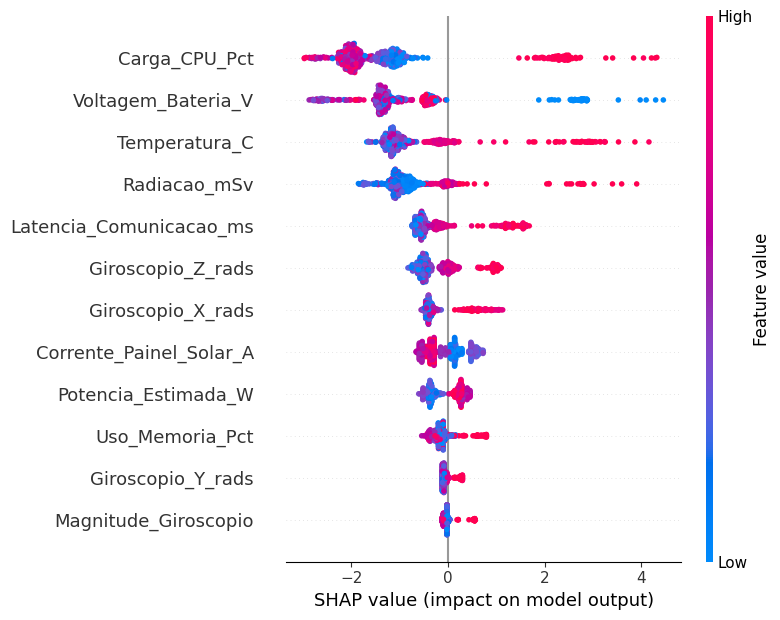

In [4]:
# Célula 4: Salvamento e SHAP (Interpretabilidade)
print("Preparando modelo para o deploy e gerando SHAP...")

# Trocando para CPU para evitar erros no deploy na nuvem
xgb_model.set_params(device='cpu') 
joblib.dump(xgb_model, 'modelo_xgboost_telemetria.pkl')

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot do resumo das features mais importantes
shap.summary_plot(shap_values, X_test)